In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES']='0'
from sklearn.cluster import KMeans, MiniBatchKMeans
import numpy as np
import librosa
from glob import glob
from umap import UMAP
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model, Model
import random 
import math
from tqdm import tqdm
from tensorflow.keras.utils import Sequence
 
from sklearn.metrics import roc_curve, auc
from audiomentations import Compose, Normalize, Gain
from mygenerator import MyGenerator

In [7]:
N = 4096  # length of 
 
fnames = glob("goldclips/*")  #this is stellwagon
random.shuffle(fnames)
mygen = MyGenerator(fnames, 64, N)

clips = glob("clips/train/*.npy")
random.shuffle(clips)
clips = random.sample(clips, 200)
clipgen = MyGenerator(clips, 64, N)  # these are the clips from the same ci_01 cuts
clipgen.__len__()
fnames

[]

In [ ]:

ausclips = glob("ausgoldclips/*.npy")
random.shuffle(ausclips)
ausclips = random.sample(ausclips, 400)
 
ausclipgen = MyGenerator(ausclips, 64, N)
 
ausclipgen.__len__()

In [3]:
models =   glob("best_exp2_24")
models

['best_exp2_24']

In [4]:
def plotModel(fp,tp, thisname, thisauc):
    plt.plot(fp,tp, label=f"{thisname} {thisauc:0.2f}")
    plt.plot([0,1],[0,1], linestyle='--',c='r')
    plt.grid( which='major', linestyle='-',c='k')
    plt.grid( which='minor', linestyle='--',c='r')

    plt.xlabel("False Positlves")
    plt.ylabel("True Positives")
    plt.legend()    
    plt.title("NOAA Passive Acoustic Data - Self Supervised Learning ")


def doModels(models, thisgenerator):
    for m in models:
        model = load_model(m)
        thisname = m
        y_test = []
        y_hat = []
        for i in  tqdm(range(100)):
            x,y = thisgenerator.__getitem__(i)  # remind that generator does augmentation
            ytmp = model.predict(x, verbose=0)
            y_test.append(y)
            y_hat.append(ytmp)
        y_test = np.hstack(y_test)
        y_hat = np.vstack (y_hat)
        fp,tp, th = roc_curve(y_test, y_hat)
        thisauc = auc(fp,tp)
        plotModel(fp,tp, thisname, thisauc)
    plt.show()
    
    


In [6]:
doModels(models, mygen)

  0%|                                                                          | 0/100 [00:00<?, ?it/s]


IndexError: list index out of range

In [ ]:
doModels(models, ausclipgen)

100%|████████████████████████████████████████████████████████████████| 100/100 [08:06<00:00,  4.87s/it]


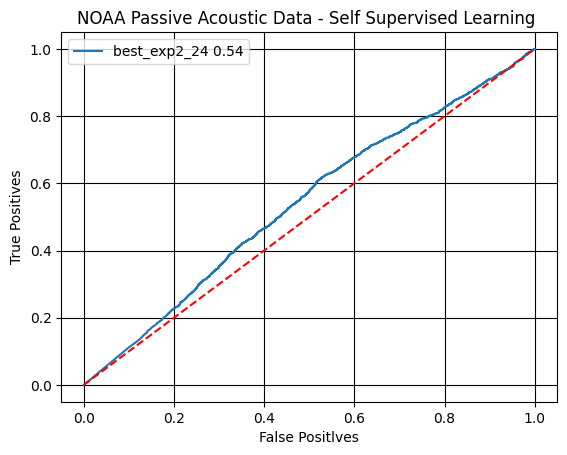

In [5]:
doModels(models, clipgen)

In [ ]:
doModels(models, ausclipgen)

In [ ]:
#  make sure to pick best model here
model=load_model(models[0])
inp = model.layers[0].input
out = model.layers[-3].output
emb = Model(inp, out)


In [ ]:
EMB_N = 128
y_hat = []
for i in  tqdm(range(40)):
    x,y = mygen.__getitem__(i)  # remind that generator does augmentation
    ytmp = emb.predict(x, verbose=0)
    y_hat.append(ytmp)
y_hat = np.array(y_hat)
y_hat = np.reshape(y_hat, (y_hat.shape[0] * y_hat.shape[1],128))

In [ ]:
clips = glob("clips/*.npy")
EMB_N = 128
random.shuffle(clips)
clipgen = MyGenerator(clips, 64, N)
clipgen.__len__()
clip_hat = []
for i in  tqdm(range(40)):
    x,y = clipgen.__getitem__(i)  # remind that generator does augmentation
    ytmp = emb.predict(x, verbose=0)
    clip_hat.append(ytmp)
clip_hat = np.array(clip_hat)
clip_hat=np.reshape(clip_hat, (clip_hat.shape[0]* clip_hat.shape[1], EMB_N))


In [ ]:

ausclips = glob("ausgoldclips/*.npy")
random.shuffle(ausclips)
ausclipgen = MyGenerator(ausclips, 64, N)
ausclipgen.__len__()
ausclip_hat = []
for i in  tqdm(range( 40)):
    x,y = ausclipgen.__getitem__(i)  # remind that generator does augmentation
    ytmp = emb.predict(x, verbose=0)
    ausclip_hat.append(ytmp)
ausclip_hat = np.array(ausclip_hat)
ausclip_hat=np.reshape(ausclip_hat, (ausclip_hat.shape[0]* ausclip_hat.shape[1], EMB_N))

In [ ]:
mapper = UMAP().fit(y_hat)
transformed = mapper.transform(clip_hat)

In [ ]:
austransformed = mapper.transform(ausclip_hat)

In [ ]:

plt.scatter(mapper.embedding_[:,0], mapper.embedding_[:,1], s=1, label='')
plt.scatter(transformed[:,0], transformed[:,1], s=1, alpha=.2)
plt.scatter(austransformed[:,0], austransformed[:,1], s=1, alpha=.2)
plt.title("")
plt.grid()

In [ ]:
#model.evaluate(ausclipgen)

In [ ]:
model.evaluate(clipgen) # I think this is test holdout from base dataset 

In [ ]:
model.evaluate(mygen)

In [ ]:
plt.hist(model.layers[-3].get_weights()[0].ravel(),bins='auto');

In [ ]:
x= mygen.__getitem__(0)[0][0][:,0]
y = clipgen.__getitem__(10)[0][0][:,0]
plt.plot(np.correlate(x,y, mode='full'))

In [ ]:
load_model(models[0]).summary()